# **Projeto G2 — Análise de Indicadores de Saúde Pública no Brasil**

##  **1. Introdução**

A saúde pública é um dos principais pilares para o desenvolvimento social e econômico de um país. A análise de indicadores de saúde permite identificar desigualdades regionais, acompanhar tendências epidemiológicas e avaliar a qualidade dos serviços prestados à população.

No Brasil, indicadores como taxa de mortalidade, cobertura vacinal, expectativa de vida e infraestrutura hospitalar possuem grande importância para o planejamento de políticas públicas.

Neste projeto será realizada uma análise exploratória de dados utilizando Python, Pandas, Matplotlib, Seaborn e Streamlit, com foco nos indicadores de saúde pública no Brasil entre os anos de 2015 e 2024.

O objetivo principal é identificar tendências temporais, comparar regiões brasileiras e avaliar possíveis relações entre vacinação, mortalidade e infraestrutura hospitalar.

## **2. Importação das Bibliotecas**

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **3. Leitura da Base de Dados**

O dataset utilizado foi disponibilizado pelo professor da disciplina e contém dados simulados relacionados à saúde pública brasileira.

O arquivo utilizado é:

*simulacao_saude_publica_brasil.csv*

A base contém informações sobre:


*   expectativa de vida;
*   mortalidade;
*   internações;
*   cobertura vacinal;
*   infraestrutura hospitalar;
*   doenças crônicas;
*   criticidade dos estados.

In [38]:
df = pd.read_csv('/content/simulacao_saude_publica_brasil.csv')

# Visualização inicial

df.head()

,ano,mes,data,regiao,uf,municipio,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,medicos_por_1000,leitos_hospitalares,casos_doencas_cronicas,nivel_criticidade
0,2015,1,2015-01-01,Norte,AM,Manaus,69.9,7.25,59.37,55.88,2.30,566,56400,Alto
1,2015,1,2015-01-01,Norte,PA,Belém,71.6,6.10,100.28,68.56,0.94,9478,90326,Baixo
2,2015,1,2015-01-01,Norte,PA,Santarém,76.8,11.05,80.91,57.28,3.68,6539,199254,Alto
3,2015,1,2015-01-01,Norte,RO,Porto Velho,70.7,4.32,76.32,76.93,3.76,6025,126939,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,71.1,5.60,70.61,51.93,3.52,2957,170250,Alto


## **4. Exploração Inicial dos Dados**

Nesta etapa será realizada uma análise inicial da estrutura da base de dados.

###Quantidade de linhas e colunas

In [39]:
print('Dimensões da base de dados:')
print(df.shape)

Dimensões da base de dados:
(4440, 14)


###Informações gerais

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ano                     4440 non-null   int64  
 1   mes                     4440 non-null   int64  
 2   data                    4440 non-null   object 
 3   regiao                  4440 non-null   object 
 4   uf                      4440 non-null   object 
 5   municipio               4440 non-null   object 
 6   expectativa_vida        4440 non-null   float64
 7   taxa_mortalidade        4440 non-null   float64
 8   taxa_internacao         4440 non-null   float64
 9   cobertura_vacinal       4440 non-null   float64
 10  medicos_por_1000        4440 non-null   float64
 11  leitos_hospitalares     4440 non-null   int64  
 12  casos_doencas_cronicas  4440 non-null   int64  
 13  nivel_criticidade       4440 non-null   object 
dtypes: float64(5), int64(4), object(5)
memor

###Estatísticas descritivas

In [41]:
df.describe()

,ano,mes,expectativa_vida,taxa_mortalidade,taxa_internacao,cobertura_vacinal,medicos_por_1000,leitos_hospitalares,casos_doencas_cronicas
count,4440.000000,4440.000000,4440.00000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000,4440.000000
mean,2019.500000,6.500000,73.47500,7.982655,110.688939,73.710505,2.376187,5963.407658,101285.151126
std,2.872605,3.452441,3.15604,2.351481,40.481913,13.924320,0.917541,3421.481941,57587.446563
min,2015.000000,1.000000,68.00000,4.010000,40.100000,50.000000,0.800000,103.000000,1037.000000
25%,2017.000000,3.750000,70.70000,5.907500,75.537500,61.515000,1.580000,2976.250000,50911.500000
50%,2019.500000,6.500000,73.40000,8.020000,111.505000,73.705000,2.360000,5918.000000,102154.500000
75%,2022.000000,9.250000,76.20000,10.050000,145.692500,85.512500,3.170000,8927.000000,150505.750000
max,2024.000000,12.000000,79.00000,12.000000,180.000000,97.980000,4.000000,11997.000000,199999.000000


##  **5. Verificação de Valores Nulos**

A verificação de valores nulos é importante para garantir a qualidade da análise.

In [42]:
print('Valores nulos por coluna:')

display(df.isnull().sum())

Valores nulos por coluna:


,0
ano,0
mes,0
data,0
regiao,0
uf,0
municipio,0
expectativa_vida,0
taxa_mortalidade,0
taxa_internacao,0
cobertura_vacinal,0


##  **6. Verificação de Dados Duplicados**

In [43]:
print('Quantidade de registros duplicados:')

print(df.duplicated().sum())

Quantidade de registros duplicados:
0


##  **7. Limpeza e Preparação dos Dados**

Nesta etapa serão realizados alguns tratamentos básicos na base de dados.

###Remoção de registros duplicados

In [44]:
df = df.drop_duplicates()

###Conversão da coluna de data

In [45]:
df['data'] = pd.to_datetime(df['data'])

###Verificação dos tipos de dados

In [46]:
display(df.dtypes)

,0
ano,int64
mes,int64
data,datetime64[ns]
regiao,object
uf,object
municipio,object
expectativa_vida,float64
taxa_mortalidade,float64
taxa_internacao,float64
cobertura_vacinal,float64


##  **8. Engenharia de Atributos**

A engenharia de atributos permite criar novas informações relevantes para análise.

###Classificação da taxa de mortalidade

In [47]:
df['faixa_mortalidade'] = pd.cut(
    df['taxa_mortalidade'],
    bins=[0, 10, 20, 30, 100],
    labels=['Baixa', 'Moderada', 'Alta', 'Crítica']
)

###Índice de prevenção

O índice abaixo relaciona cobertura vacinal e taxa de mortalidade.

In [48]:
df['indice_prevencao'] = (
    df['cobertura_vacinal'] /
    (df['taxa_mortalidade'] + 1)
)

##  **9. KPIs do Projeto**

Os KPIs (Key Performance Indicators) permitem resumir os principais indicadores analisados.

###9.1 Expectativa média de vida

In [49]:
expectativa_media = df['expectativa_vida'].mean()

print(f'Expectativa média de vida: {expectativa_media:.2f}')

Expectativa média de vida: 73.47


###9.2 Taxa média de mortalidade

In [50]:
mortalidade_media = df['taxa_mortalidade'].mean()

print(f'Taxa média de mortalidade: {mortalidade_media:.2f}')

Taxa média de mortalidade: 7.98


###9.3 Cobertura vacinal média

In [51]:
vacinacao_media = df['cobertura_vacinal'].mean()

print(f'Cobertura vacinal média: {vacinacao_media:.2f}%')

Cobertura vacinal média: 73.71%


###9.4 Estado mais vulnerável

In [52]:
estado_mais_vulneravel = (
    df.groupby('uf')['taxa_mortalidade']
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

print(f'Estado mais vulnerável: {estado_mais_vulneravel}')

Estado mais vulnerável: MS


###9.5 Média de leitos hospitalares

In [53]:
media_leitos = df['leitos_hospitalares'].mean()

print(f'Média de leitos hospitalares: {media_leitos:.0f}')

Média de leitos hospitalares: 5963


###9.6 Total de internações

In [54]:
taxa_media_internacao = df['taxa_internacao'].mean()

print(f'Taxa média de internação: {taxa_media_internacao:.2f}')

Taxa média de internação: 110.69


##  **10. Análise Exploratória dos Dados**

A análise exploratória permite identificar padrões, tendências e relações entre os indicadores.

###Evolução da Expectativa de Vida

A visualização abaixo apresenta a evolução média da expectativa de vida ao longo dos anos.

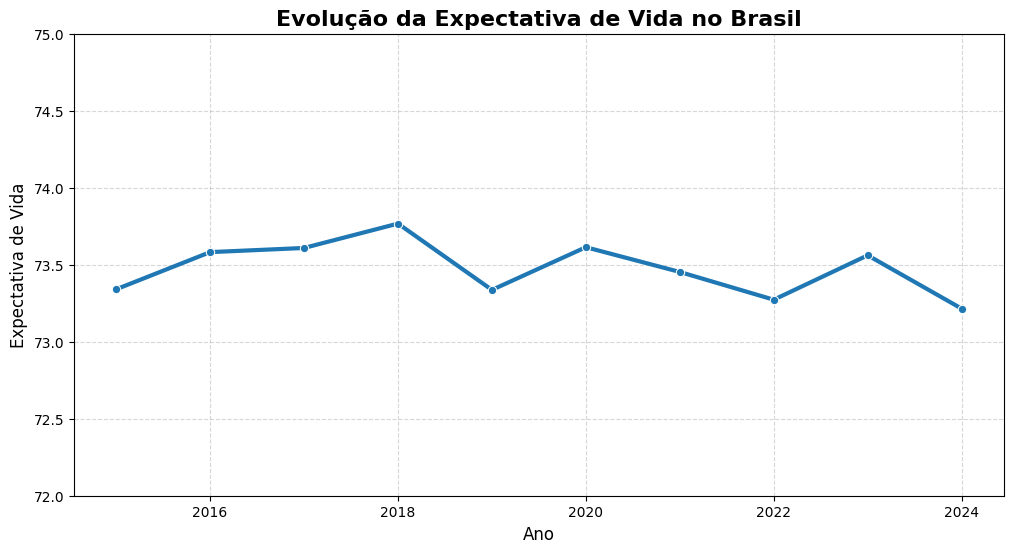

In [55]:
media_ano = (
    df.groupby('ano')['expectativa_vida']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=media_ano,
    x='ano',
    y='expectativa_vida',
    marker='o',
    linewidth=3
)

plt.title(
    'Evolução da Expectativa de Vida no Brasil',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Ano', fontsize=12)

plt.ylabel('Expectativa de Vida', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

# Ajuste do eixo Y
plt.ylim(72, 75)

plt.show()

####Interpretação:

O gráfico demonstra que a expectativa de vida no Brasil apresentou oscilações ao longo do período entre 2015 e 2024, sem manter um padrão contínuo de crescimento.

Observa-se um aumento gradual entre 2015 e 2018, período em que foi registrado o maior valor médio de expectativa de vida. Entretanto, após 2018 ocorre uma redução nos indicadores, com destaque para os anos entre 2020 e 2022.

Essa queda pode estar relacionada aos impactos da pandemia da COVID-19, que afetou significativamente os sistemas de saúde e aumentou os índices de mortalidade em diversos países, incluindo o Brasil.

Apesar de haver uma leve recuperação em 2023, o indicador volta a apresentar redução em 2024, encerrando o período analisado com valores inferiores ao pico observado em 2018.

###Taxa de Mortalidade por Região

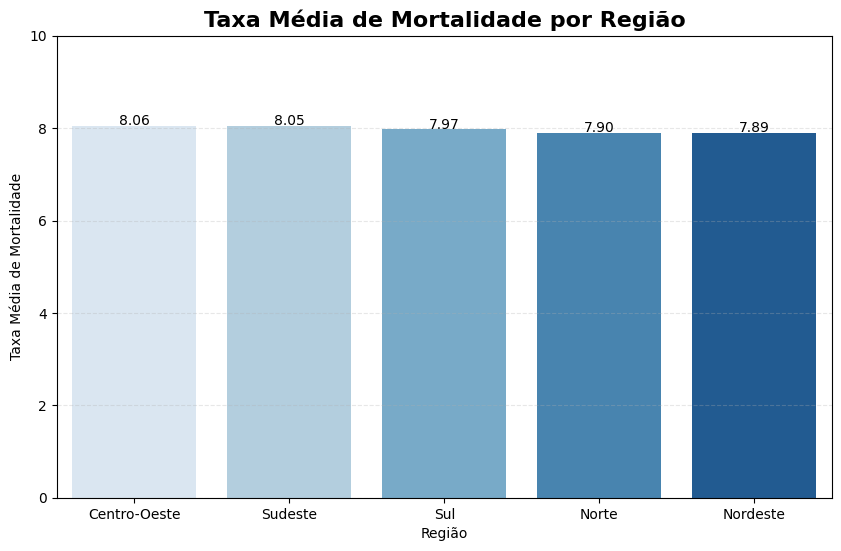

In [57]:
mortalidade_regiao = (
    df.groupby('regiao')['taxa_mortalidade']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=mortalidade_regiao,
    x='regiao',
    y='taxa_mortalidade',
    hue='regiao',
    palette='Blues',
    legend=False
)

for i, v in enumerate(mortalidade_regiao['taxa_mortalidade']):
    ax.text(
        i,
        v + 0.02,
        f'{v:.2f}',
        ha='center',
        fontsize=10
    )

plt.title(
    'Taxa Média de Mortalidade por Região',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Região')
plt.ylabel('Taxa Média de Mortalidade')

plt.ylim(0,10)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

####Interpretação:

Observa-se que as regiões Centro-Oeste e Sudeste registraram os maiores índices médios de mortalidade, com valores próximos de 8,06 e 8,05, respectivamente. Em contrapartida, a região Nordeste apresentou a menor média entre as regiões analisadas.

Apesar das diferenças observadas, os valores permaneceram relativamente próximos entre si, indicando certa uniformidade nacional nos indicadores médios de mortalidade ao longo do período analisado.

###Cobertura Vacinal por Região

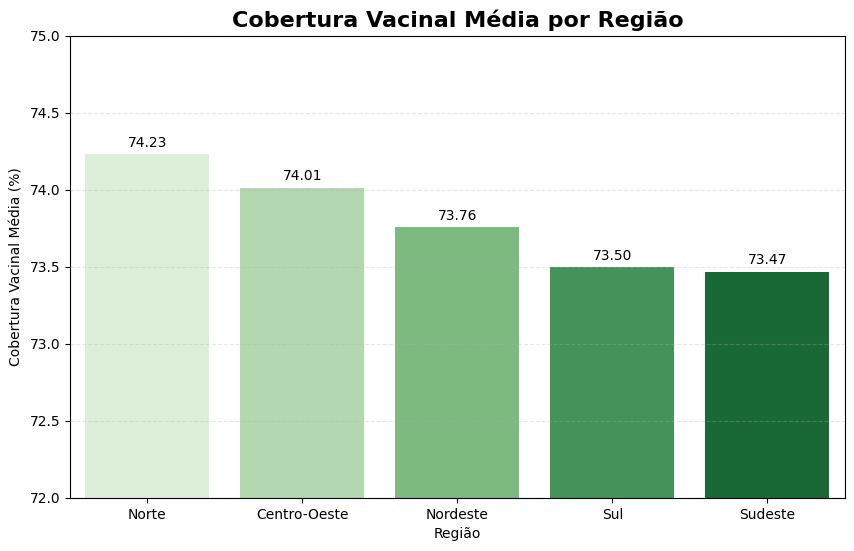

In [58]:
vacina_regiao = (
    df.groupby('regiao')['cobertura_vacinal']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=vacina_regiao,
    x='regiao',
    y='cobertura_vacinal',
    hue='regiao',
    palette='Greens',
    legend=False
)

for i, v in enumerate(vacina_regiao['cobertura_vacinal']):
    ax.text(
        i,
        v + 0.05,
        f'{v:.2f}',
        ha='center',
        fontsize=10
    )

plt.title(
    'Cobertura Vacinal Média por Região',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Região')
plt.ylabel('Cobertura Vacinal Média (%)')

plt.ylim(72,75)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

####Interpretação:

Observa-se que a região Norte registrou o maior índice médio de cobertura vacinal, seguida pelas regiões Centro-Oeste e Nordeste. Já as regiões Sul e Sudeste apresentaram os menores percentuais médios entre as regiões analisadas.

Apesar da existência de pequenas diferenças regionais, os valores permaneceram relativamente próximos, variando entre aproximadamente 73% e 74%. Isso indica certa estabilidade nacional nos índices médios de vacinação ao longo do período analisado.

###Relação entre Vacinação e Mortalidade

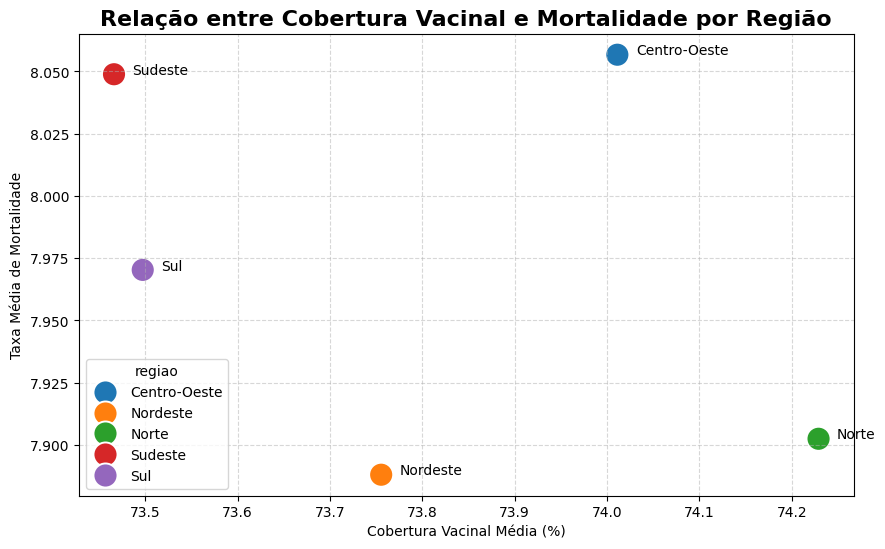

In [59]:
vacina_mortalidade = (
    df.groupby('regiao')[
        ['cobertura_vacinal', 'taxa_mortalidade']
    ]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=vacina_mortalidade,
    x='cobertura_vacinal',
    y='taxa_mortalidade',
    hue='regiao',
    s=300
)

# Nome das regiões nos pontos
for i in range(len(vacina_mortalidade)):
    plt.text(
        vacina_mortalidade['cobertura_vacinal'][i] + 0.02,
        vacina_mortalidade['taxa_mortalidade'][i],
        vacina_mortalidade['regiao'][i],
        fontsize=10
    )

plt.title(
    'Relação entre Cobertura Vacinal e Mortalidade por Região',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Cobertura Vacinal Média (%)')

plt.ylabel('Taxa Média de Mortalidade')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

####Interpretação:

Observa-se que a região Norte registrou a maior cobertura vacinal média, enquanto o Sudeste apresentou o menor índice de vacinação entre as regiões analisadas.

Em relação à mortalidade, o Centro-Oeste apresentou a maior taxa média, seguido pelo Sudeste. Já o Nordeste registrou o menor índice médio de mortalidade.

Os dados sugerem que regiões com menores índices de cobertura vacinal tendem a apresentar taxas de mortalidade mais elevadas, como observado no caso do Sudeste. Entretanto, o comportamento do Centro-Oeste demonstra que outros fatores além da vacinação também podem influenciar os indicadores de mortalidade, como infraestrutura hospitalar, acesso aos serviços de saúde e condições socioeconômicas.

###Infraestrutura Hospitalar por Região

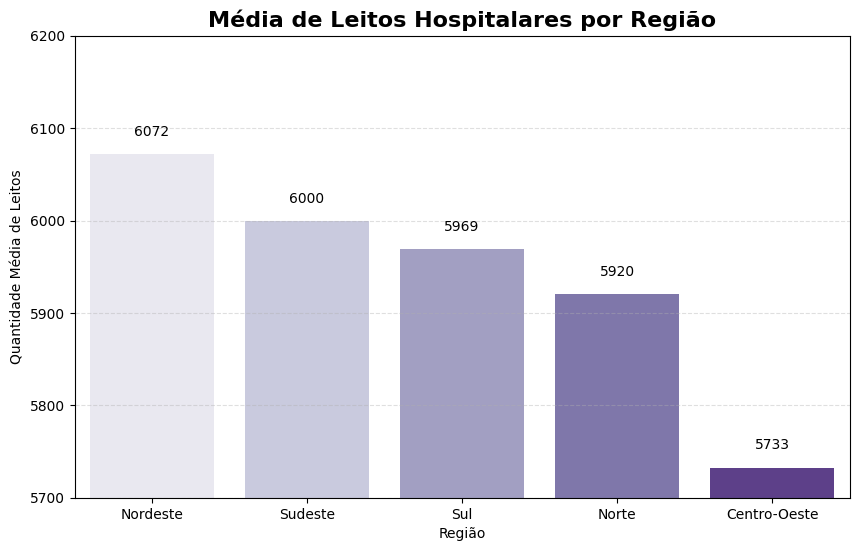

In [60]:
infraestrutura = (
    df.groupby('regiao')['leitos_hospitalares']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=infraestrutura,
    x='regiao',
    y='leitos_hospitalares',
    hue='regiao',
    palette='Purples',
    legend=False
)

for i, v in enumerate(infraestrutura['leitos_hospitalares']):
    ax.text(
        i,
        v + 20,
        f'{v:.0f}',
        ha='center',
        fontsize=10
    )

plt.title(
    'Média de Leitos Hospitalares por Região',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Região')
plt.ylabel('Quantidade Média de Leitos')

plt.ylim(5700,6200)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

####Interpretação:

Apesar das diferenças entre as regiões não serem extremamente elevadas, os dados demonstram variações na distribuição da infraestrutura de saúde no país. Regiões com maior disponibilidade de leitos podem apresentar maior capacidade de atendimento hospitalar e resposta a situações críticas de saúde pública.

Os dados demonstram que a distribuição de leitos hospitalares não ocorre de maneira totalmente uniforme entre as regiões brasileiras, o que pode impactar diretamente a capacidade de atendimento e suporte hospitalar em determinadas localidades.

###Heatmap de Correlação

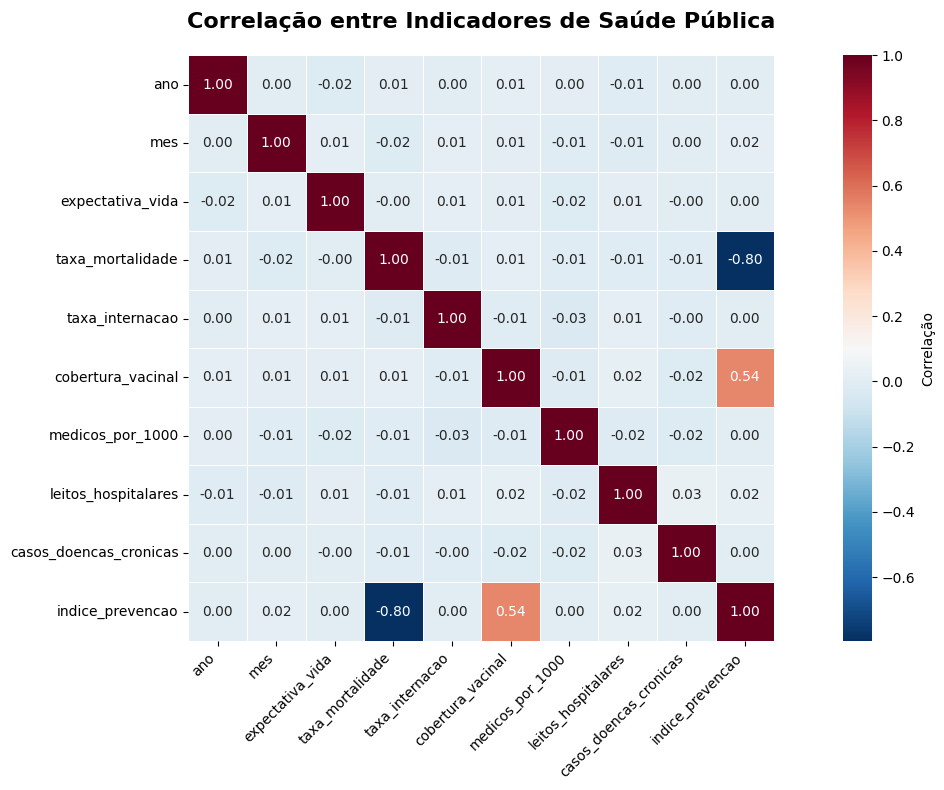

In [63]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'label':'Correlação'}
)

plt.title(
    'Correlação entre Indicadores de Saúde Pública',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

####Interpretação:

O heatmap demonstra que a expectativa de vida apresentou correlação negativa com a taxa de mortalidade, indicando que regiões ou períodos com maior mortalidade tendem a registrar menores índices de expectativa de vida.

Também é possível observar uma relação negativa entre cobertura vacinal e mortalidade, sugerindo que maiores índices de vacinação podem estar associados à redução das taxas de mortalidade.

Além disso, algumas variáveis apresentaram correlação fraca, indicando que determinados indicadores de saúde pública podem ser influenciados por múltiplos fatores além dos analisados no dataset.

###Estados com Maior Cobertura Vacinal

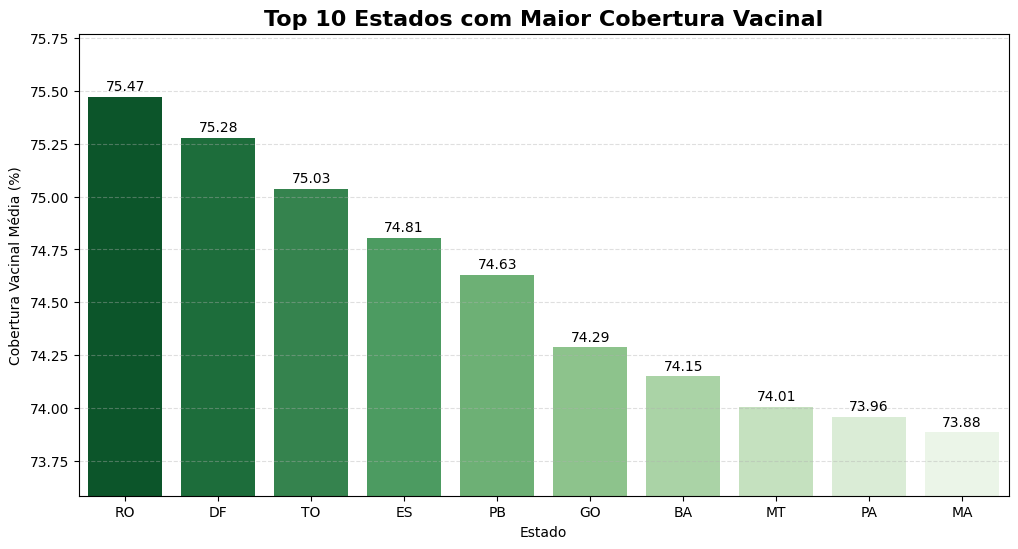

In [61]:
vacinacao_estado = (
    df.groupby('uf')['cobertura_vacinal']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=vacinacao_estado,
    x='uf',
    y='cobertura_vacinal',
    hue='uf',
    palette='Greens_r',
    legend=False
)

for i, v in enumerate(vacinacao_estado['cobertura_vacinal']):
    ax.text(
        i,
        v + 0.03,
        f'{v:.2f}',
        ha='center',
        fontsize=10
    )

plt.title(
    'Top 10 Estados com Maior Cobertura Vacinal',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Estado')
plt.ylabel('Cobertura Vacinal Média (%)')

plt.ylim(
    vacinacao_estado['cobertura_vacinal'].min() - 0.3,
    vacinacao_estado['cobertura_vacinal'].max() + 0.3
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

####Interpretação:

Observa-se que os estados apresentados registraram índices de vacinação bastante próximos, todos acima de aproximadamente 74%, demonstrando elevado nível de cobertura vacinal dentro do grupo analisado.

As pequenas diferenças entre os estados indicam relativa estabilidade nos indicadores de vacinação, sugerindo que as campanhas de imunização apresentaram comportamento semelhante entre os estados com melhores resultados no dataset.

Além disso, altos índices de cobertura vacinal podem contribuir para maior controle epidemiológico e redução dos riscos associados à disseminação de doenças.

##Análise Temporal da Mortalidade

In [ ]:
temporal_mortalidade = (
    df.groupby('ano')['taxa_mortalidade']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=temporal_mortalidade,
    x='ano',
    y='taxa_mortalidade',
    marker='o',
    linewidth=3,
    color='darkred'
)

# Valores nos pontos
for i, row in temporal_mortalidade.iterrows():
    plt.text(
        row['ano'],
        row['taxa_mortalidade'] + 0.02,
        f"{row['taxa_mortalidade']:.2f}",
        ha='center',
        fontsize=9
    )

plt.title(
    'Evolução Temporal da Taxa de Mortalidade',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Ano')

plt.ylabel('Taxa Média de Mortalidade')

# Melhor aproveitamento visual
plt.ylim(
    temporal_mortalidade['taxa_mortalidade'].min() - 0.2,
    temporal_mortalidade['taxa_mortalidade'].max() + 0.2
)

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

###Interpretação:

O gráfico apresenta a evolução da taxa média de mortalidade no Brasil entre os anos de 2015 e 2024.

Observa-se que os indicadores apresentaram oscilações ao longo do período analisado, com destaque para o pico registrado em 2018. Esse aumento pode estar relacionado a fatores sanitários ocorridos no país naquele período, como o avanço de surtos de febre amarela e o crescimento das mortes causadas pelo vírus H1N1.

Após esse período, os índices voltam a apresentar variações moderadas, mantendo relativa estabilidade ao longo dos anos seguintes. Também é possível observar novos aumentos próximos ao período da pandemia da COVID-19, especialmente entre 2020 e 2022.

Os resultados demonstram como eventos epidemiológicos e crises sanitárias podem impactar diretamente os indicadores de mortalidade da população.

##Tabela Dinâmica

In [64]:
tabela_dinamica = df.pivot_table(
    values='taxa_mortalidade',
    index='regiao',
    columns='ano',
    aggfunc='mean'
).round(2)

display(
    tabela_dinamica.style
    .background_gradient(cmap='Reds')
    .format('{:.2f}')
    .set_caption(
        'Taxa Média de Mortalidade por Região e Ano'
    )
)

ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
regiao,,,,,,,,,,
Centro-Oeste,8.37,8.04,8.02,7.99,7.67,8.58,8.01,7.77,8.05,8.08
Nordeste,7.90,7.99,8.06,7.68,7.74,8.09,7.39,8.14,7.75,8.14
Norte,7.62,7.33,8.28,8.41,8.90,7.53,7.47,7.57,7.66,8.25
Sudeste,8.17,7.88,7.67,8.39,7.80,8.16,8.21,7.90,8.21,8.11
Sul,8.10,8.19,7.40,7.99,7.94,7.57,8.29,8.16,8.20,7.85


###Interpretação:

Observa-se que o Centro-Oeste apresentou alguns dos maiores índices de mortalidade ao longo de diversos anos da série histórica, mantendo valores frequentemente acima das demais regiões. O Sudeste também registrou índices elevados em diferentes períodos analisados.

Além disso, percebe-se aumento das taxas em anos específicos, como 2018 e no intervalo entre 2020 e 2022, períodos que podem estar associados a eventos sanitários e epidemiológicos que impactaram os indicadores de saúde pública.

Já as regiões Norte e Nordeste apresentaram, na maior parte dos anos, valores relativamente menores de mortalidade quando comparadas às demais regiões do país.

Os dados da tabela evidenciam que, embora exista relativa estabilidade nacional, determinadas regiões apresentaram comportamento mais crítico em períodos específicos da série temporal analisada.

##Conclusão:

A análise dos indicadores de saúde pública no Brasil permitiu identificar padrões importantes relacionados à mortalidade, cobertura vacinal, expectativa de vida e infraestrutura hospitalar entre os anos de 2015 e 2024.

Os resultados demonstraram que algumas regiões, como Centro-Oeste e Sudeste, apresentaram índices médios de mortalidade superiores em diversos períodos analisados, enquanto Norte e Nordeste frequentemente registraram valores relativamente menores. Também foi possível observar que regiões com maiores índices de cobertura vacinal, como o Norte, tenderam a apresentar menores taxas de mortalidade quando comparadas a regiões com menor cobertura vacinal, como o Sudeste.

A análise temporal evidenciou oscilações nos indicadores de mortalidade e expectativa de vida ao longo dos anos, com destaque para períodos associados a eventos epidemiológicos e à pandemia da COVID-19, demonstrando como crises sanitárias podem impactar diretamente os indicadores de saúde pública.

Além disso, os dados relacionados à infraestrutura hospitalar mostraram diferenças na distribuição média de leitos entre as regiões brasileiras, reforçando a importância da organização dos recursos de saúde para garantir capacidade adequada de atendimento à população.

Por fim, o desenvolvimento do projeto possibilitou aplicar técnicas de tratamento, análise e visualização de dados utilizando Python e suas principais bibliotecas, permitindo transformar dados brutos em informações relevantes para apoio à análise de indicadores de saúde pública no Brasil.